In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

#### 데이터 준비
* 각 변수의 의미 파악
* 각 변수의 데이터 유형
* 각 변수의 분포와 특성 파악
* 결측치/이상치 파악
* 집값 예측을 위한 후보변수 선택

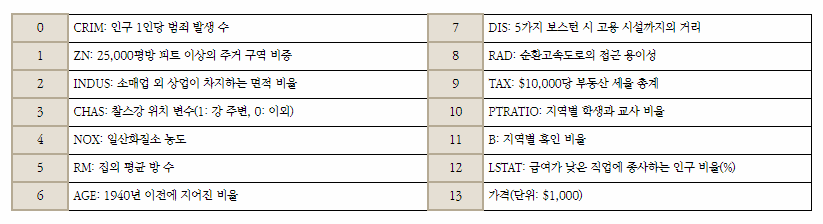

In [29]:
df = pd.read_csv('data/boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


#### 데이터 탐색

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [31]:
# 데이터 타입, 결측치 확인
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

### CHAS는 범주형 나머지는 다 수치형
- 구분하기

In [32]:
cat_cols = ['CHAS']
num_cols = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT']

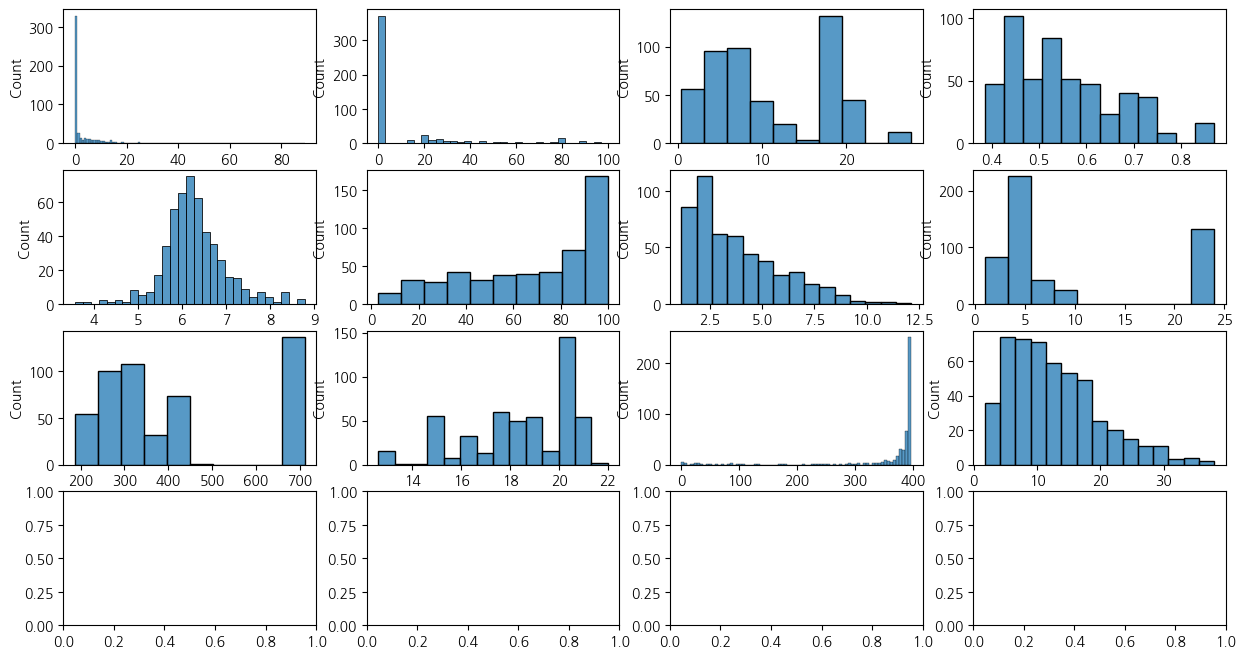

In [33]:
# 시각화
fig, ax = plt.subplots(4,4,figsize=(15,8))
axes=ax.flatten() # 여러 개의 서브플롯(axes 객체들)을 2차원 배열 형태로 만들었을 때, 그 2차원 배열을 1차원 배열로 평탄화(flatten)한다
for i, feature in enumerate(num_cols):
    sns.histplot(x=feature, data=df, ax=axes[i])
#     axes[i].set_title(feature)
# plt.tight_layout()

<Axes: xlabel='CHAS', ylabel='count'>

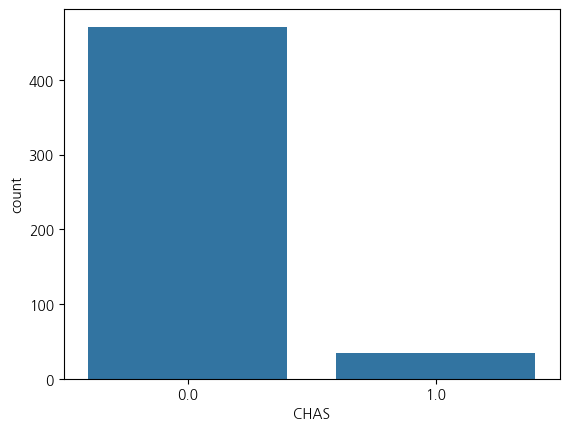

In [34]:
sns.countplot(x='CHAS', data=df)

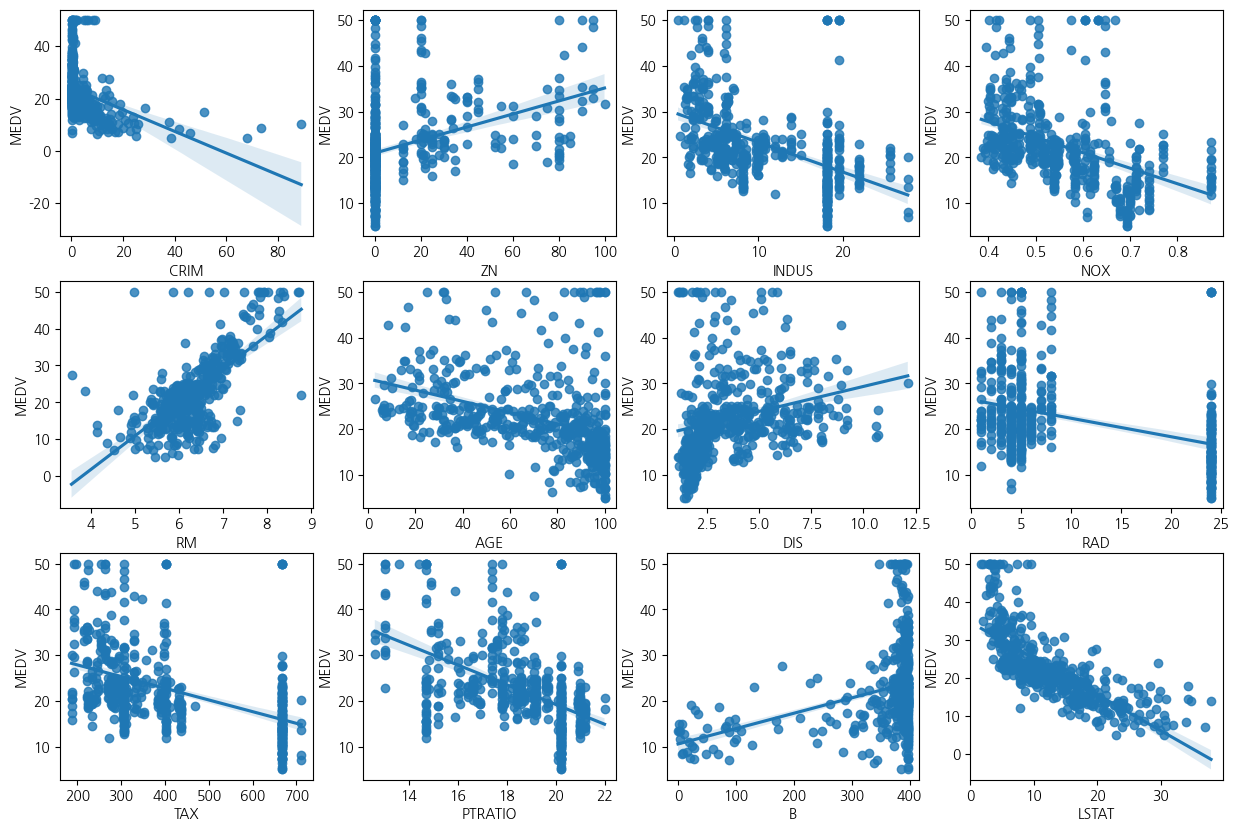

In [35]:
# 종속변수와의 상관관계

fig, ax = plt.subplots(3,4,figsize=(15,10))
axes=ax.flatten() 
for i, feature in enumerate(num_cols):
    sns.regplot(x=feature, y='MEDV', data=df, ax=axes[i])

### 다중공선성
- 다중공선성이 존재하는 변수 중에서 차원축소 하거나 종속변수와의 관계가 미미한 변수를 보통 제외하고 진행함
- 다중공선성이 존재한다고 반드시 빼야하는 건 아님 (모델 성능이 무조건 내려가는게 아님)

<Axes: >

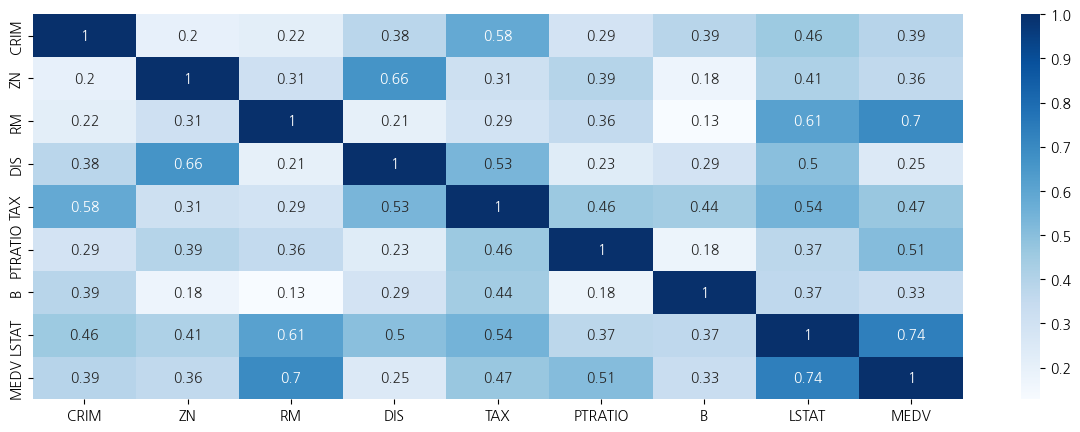

In [36]:
# 상관계수 / 다중공선성 검사
plt.figure(figsize = (15, 5))
sns.heatmap(abs(df.drop(['CHAS', 'INDUS', "NOX", 'AGE', 'RAD'], axis = 1).corr()), cmap = 'Blues', annot = True)
# abs(df.drop(['CHAS'], axis = 1).corr())  상관관계 볼 때는 절댓값으로 보는게 편함
# 다른 독립변수와 상관계수가 높은 INDUS, NOX, AGE 빼보기 (임의로)

<Axes: xlabel='CHAS', ylabel='MEDV'>

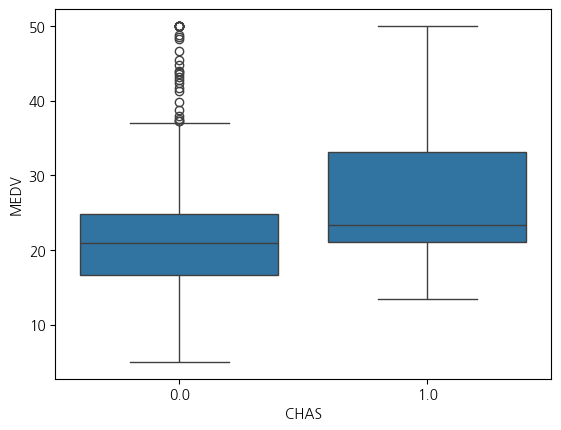

In [37]:
# 범주형 변수와 종속변수와의 관계 보기
sns.boxplot(x='CHAS', y='MEDV', data=df)
# 찰스강 주변의 집이 가격이 좀 더 높음

#### 변수 선택

In [38]:
# 독립변수, 종속변수 선택
del_cols = ['MEDV', 'INDUS', "NOX", 'AGE', 'RAD'] # 독립변수에서 제외할 변수 선택택

X = df.drop(del_cols, axis=1).copy() # 데이터프레임 형태로 지정해줘야함
y = df['MEDV']

X.head()

,CRIM,ZN,CHAS,RM,DIS,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,0.0,6.575,4.0900,296.0,15.3,396.90,4.98
1,0.02731,0.0,0.0,6.421,4.9671,242.0,17.8,396.90,9.14
2,0.02729,0.0,0.0,7.185,4.9671,242.0,17.8,392.83,4.03
3,0.03237,0.0,0.0,6.998,6.0622,222.0,18.7,394.63,2.94
4,0.06905,0.0,0.0,7.147,6.0622,222.0,18.7,396.90,5.33


#### 훈련세트, 테스트세트 분할

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(379, 9) (127, 9) (379,) (127,)


#### 데이터 전처리 - 스케일링

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

train_scaled = scaler.fit_transform(X_train)  # 훈련데이터는 fit_transform()
test_scaled = scaler.transform(X_test)        # 테스트데이터는 transform()

In [41]:
# ------------------------------------------
# 독립변수 데이터프레임 형태로 변환
# ------------------------------------------
X_train_scaled = pd.DataFrame(train_scaled, columns=X_train.columns, index = X_train.index)
X_test_scaled = pd.DataFrame(test_scaled, columns=X_test.columns, index = X_test.index)

In [42]:
X_train_preprocessed = pd.concat([X_train_scaled, X_train['CHAS']], axis = 1)
X_test_preprocessed = pd.concat([X_test_scaled, X_test['CHAS']], axis = 1)

# concat시의 기준이 인덱스인데 X_train_scaled는 인덱스가 초기화된거고, CHAS는 원래 인덱스라서 null이 생겨버림

In [43]:
X_train_preprocessed

,CRIM,ZN,CHAS,RM,DIS,TAX,PTRATIO,B,LSTAT,CHAS
182,-0.406795,-0.502812,-0.287849,1.156255,-0.503753,-1.280208,-0.205157,0.404512,-1.077756,0.0
155,0.007992,-0.502812,3.474042,-0.238475,-0.956440,-0.013937,-1.576252,-3.098037,0.351165,1.0
280,-0.413450,0.364381,-0.287849,2.080976,0.441388,-1.141522,-1.487795,0.326591,-1.226252,0.0
126,-0.371107,-0.502812,-0.287849,-0.987986,-0.950895,-1.310358,0.369819,0.005983,2.065870,0.0
329,-0.409661,-0.502812,-0.287849,0.013216,0.687804,0.148869,-0.603217,0.188141,-0.724729,0.0
...,...,...,...,...,...,...,...,...,...,...
106,-0.397140,-0.502812,-0.287849,-0.677892,-0.735808,-0.128504,1.165939,0.422247,0.861093,0.0
270,-0.381729,0.364381,-0.287849,-0.650081,0.315455,-1.099312,0.148674,0.341924,0.068182,0.0
348,-0.415951,2.965961,-0.287849,0.433164,2.171042,-0.755610,-0.558988,0.368126,-0.913851,0.0
435,0.926381,-0.502812,-0.287849,0.424821,-0.776711,1.571917,0.856337,-2.848141,1.506909,0.0


In [44]:
X_train_scaled.describe()

,CRIM,ZN,CHAS,RM,DIS,TAX,PTRATIO,B,LSTAT
count,3.790000e+02,3.790000e+02,3.790000e+02,3.790000e+02,3.790000e+02,3.790000e+02,3.790000e+02,3.790000e+02,3.790000e+02
mean,-8.436523e-17,2.226305e-17,-1.640435e-17,-4.921305e-17,1.406087e-17,9.725437e-17,-7.827219e-16,-1.171739e-17,-2.238022e-16
std,1.001322e+00,1.001322e+00,1.001322e+00,1.001322e+00,1.001322e+00,1.001322e+00,1.001322e+00,1.001322e+00,1.001322e+00
min,-4.166677e-01,-5.028120e-01,-2.878492e-01,-3.421464e+00,-1.248358e+00,-1.316388e+00,-2.505059e+00,-4.101397e+00,-1.510635e+00
25%,-4.078913e-01,-5.028120e-01,-2.878492e-01,-6.028016e-01,-8.000780e-01,-7.616401e-01,-7.359034e-01,1.987826e-01,-7.912717e-01
50%,-3.853152e-01,-5.028120e-01,-2.878492e-01,-1.355740e-01,-3.087147e-01,-4.541171e-01,1.486744e-01,3.727030e-01,-1.811785e-01
75%,-2.725877e-02,3.643814e-01,-2.878492e-01,4.741860e-01,7.050332e-01,1.571917e+00,8.563367e-01,4.232772e-01,5.437887e-01
max,1.029838e+01,3.833155e+00,3.474042e+00,3.415913e+00,3.963829e+00,1.843261e+00,1.652457e+00,4.363212e-01,3.566236e+00


#### 예측 및 평가

In [45]:
# ------------------------------------------
# LinearRegression 클래스 import
# ------------------------------------------
from sklearn.linear_model import LinearRegression

# ------------------------------------------
# 모델객체 생성하기
# ------------------------------------------
model = LinearRegression()

# ------------------------------------------
# 훈련데이터로 모델 훈련하기
# ------------------------------------------
model.fit(X_train_preprocessed, y_train)


LinearRegression()

In [46]:
from sklearn.metrics import mean_squared_error, \
                            mean_absolute_error, \
                            root_mean_squared_error, \
                            r2_score

# -----------------------------------
# 테스트데이터의 예측값
# -----------------------------------
y_pred = model.predict(X_test_preprocessed)

# -----------------------------------
# 모델 평가
# -----------------------------------
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('===다중회귀 모델의 평가결과===')
print(f'R2:{r2:.4f}')
print(f'RMSE:{rmse:.4f}')
print(f'MAE:{mae:.4f}')
print(f'MSE:{mse:.4f}')

===다중회귀 모델의 평가결과===
R2:0.6436
RMSE:4.9959
MAE:3.1773
MSE:24.9591


In [47]:
# ------------------------------------------
# LinearRegression 클래스 import
# ------------------------------------------
from sklearn.tree import DecisionTreeRegressor

# ------------------------------------------
# 모델객체 생성하기
# ------------------------------------------
model2 = DecisionTreeRegressor()

# ------------------------------------------
# 훈련데이터로 모델 훈련하기
# ------------------------------------------
model2.fit(X_train_preprocessed, y_train)


DecisionTreeRegressor()

In [48]:
from sklearn.metrics import mean_squared_error, \
                            mean_absolute_error, \
                            root_mean_squared_error, \
                            r2_score

# -----------------------------------
# 테스트데이터의 예측값
# -----------------------------------
y_pred2 = model2.predict(X_test_preprocessed)

# -----------------------------------
# 모델 평가
# -----------------------------------
mse = mean_squared_error(y_test, y_pred2)
rmse = root_mean_squared_error(y_test, y_pred2)
mae = mean_absolute_error(y_test, y_pred2)
r2 = r2_score(y_test, y_pred2)

print('===다중회귀 모델의 평가결과===')
print(f'R2:{r2:.4f}')
print(f'RMSE:{rmse:.4f}')
print(f'MAE:{mae:.4f}')
print(f'MSE:{mse:.4f}')

===다중회귀 모델의 평가결과===
R2:0.7529
RMSE:4.1599
MAE:2.9315
MSE:17.3046


In [51]:
# ------------------------------------------
# LinearRegression 클래스 import
# ------------------------------------------
from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------
# 모델객체 생성하기
# ------------------------------------------
model3 = RandomForestRegressor()

# ------------------------------------------
# 훈련데이터로 모델 훈련하기
# ------------------------------------------
model3.fit(X_train_preprocessed, y_train)

RandomForestRegressor()

In [53]:
from sklearn.metrics import mean_squared_error, \
                            mean_absolute_error, \
                            root_mean_squared_error, \
                            r2_score

# -----------------------------------
# 테스트데이터의 예측값
# -----------------------------------
y_pred3 = model3.predict(X_test_preprocessed)

# -----------------------------------
# 모델 평가
# -----------------------------------
mse = mean_squared_error(y_test, y_pred3)
rmse = root_mean_squared_error(y_test, y_pred3)
mae = mean_absolute_error(y_test, y_pred3)
r2 = r2_score(y_test, y_pred3)

print('===다중회귀 모델의 평가결과===')
print(f'R2:{r2:.4f}')
print(f'RMSE:{rmse:.4f}')
print(f'MAE:{mae:.4f}')
print(f'MSE:{mse:.4f}')

===다중회귀 모델의 평가결과===
R2:0.8333
RMSE:3.4168
MAE:2.2551
MSE:11.6747


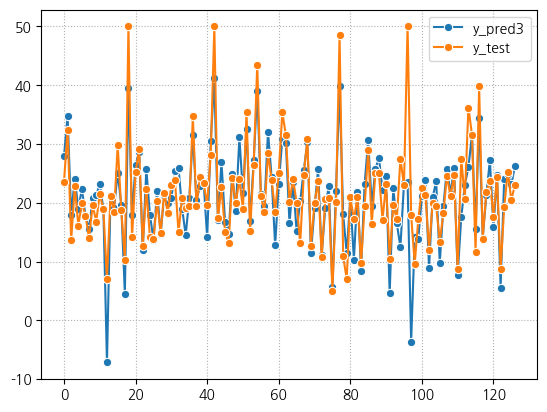

In [55]:
sns.lineplot(y_pred, marker='o', label='y_pred3')
sns.lineplot(np.array(y_test), marker='o', label='y_test')
plt.grid(ls=':')
plt.legend()
pass

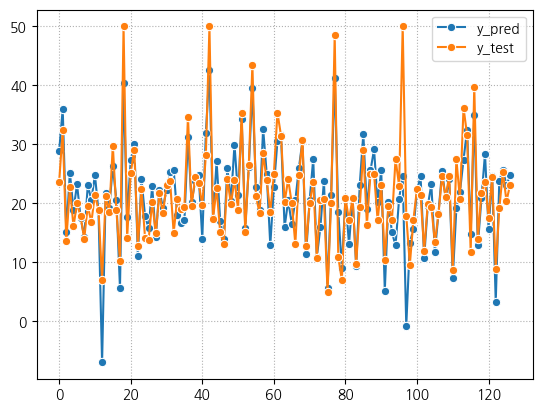

In [16]:
sns.lineplot(y_pred, marker='o', label='y_pred')
sns.lineplot(np.array(y_test), marker='o', label='y_test')
plt.grid(ls=':')
plt.legend()
pass